In [1]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
anklet = pd.read_csv('anklet.csv', sep=';')
auth_group = pd.read_csv('auth_group.csv', sep=';')
auth_permission = pd.read_csv('auth_permission.csv', sep=';')
auth_token = pd.read_csv('authtoken_token.csv', sep=';')
company = pd.read_csv('company.csv', sep=';')

orderproducts = pd.read_csv('orderproducts.csv')
orders = pd.read_csv('orders.csv', sep=';')
payment = pd.read_csv('payment.csv')
product = pd.read_csv('product.csv' , sep=';')
product_categories = pd.read_csv('product_categories.csv')
products_category = pd.read_csv('products_category.csv')
purchase_orders = pd.read_csv('purchase_orders.csv')
users = pd.read_csv('users.csv', sep=';')

In [15]:
orders.shape

(29371, 23)

In [3]:
orders.head()




,id,created_at,updated_at,number,subtotal,rest_to_pay,total_not_paid,tva,number_person,access_time,...,customer_id,discount,total,total_ht,total_paid,type,access_date,user_id,number_sock,discount5
0,59,2023-03-30 13:24:30.113+01,2023-04-03 22:48:10.123+01,"2,3033E+11",68.0,0.0,0.0,4.449,2,14:00:00,...,21347,0,68.0,63.551,68.0,NaN,01/04/2023,11,0,0
1,60,2023-03-30 13:40:55.205+01,2023-04-03 22:48:20.005+01,"2,3033E+11",68.0,0.0,0.0,4.449,2,14:00:00,...,21348,0,68.0,63.551,68.0,NaN,01/04/2023,11,0,0
2,61,2023-03-30 13:57:59.039+01,2023-04-03 22:48:31.223+01,"2,3033E+11",23.0,0.0,0.0,1.505,1,14:00:00,...,7554,0,23.0,21.495,23.0,NaN,01/04/2023,11,0,0
3,62,2023-03-30 14:00:37.48+01,2023-04-03 22:48:39.385+01,"2,3033E+11",15.0,0.0,0.0,0.981,1,14:00:00,...,21349,0,15.0,14.019,15.0,NaN,01/04/2023,11,0,0
4,64,2023-03-30 14:13:39.361+01,2023-04-03 22:48:51.99+01,"2,3033E+11",68.0,0.0,0.0,4.449,2,14:00:00,...,21351,0,68.0,63.551,68.0,NaN,01/04/2023,11,0,0


In [10]:
orders.columns

Index(['id', 'created_at', 'updated_at', 'number', 'subtotal', 'rest_to_pay',
       'total_not_paid', 'tva', 'number_person', 'access_time', 'status',
       'is_archived', 'is_archived_at', 'customer_id', 'discount', 'total',
       'total_ht', 'total_paid', 'type', 'access_date', 'user_id',
       'number_sock', 'discount5'],
      dtype='object')

In [4]:
print(orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29371 entries, 0 to 29370
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              29371 non-null  int64  
 1   created_at      29371 non-null  object 
 2   updated_at      29371 non-null  object 
 3   number          29371 non-null  object 
 4   subtotal        29371 non-null  float64
 5   rest_to_pay     29371 non-null  float64
 6   total_not_paid  29371 non-null  float64
 7   tva             29371 non-null  float64
 8   number_person   29371 non-null  int64  
 9   access_time     29371 non-null  object 
 10  status          29371 non-null  object 
 11  is_archived     29371 non-null  object 
 12  is_archived_at  0 non-null      float64
 13  customer_id     29371 non-null  int64  
 14  discount        29371 non-null  int64  
 15  total           29371 non-null  float64
 16  total_ht        29371 non-null  float64
 17  total_paid      29371 non-null 

In [6]:
# Check for missing values
print(orders.isnull().sum())

# Check data types
print(orders.dtypes)

id                    0
created_at            0
updated_at            0
number                0
subtotal              0
rest_to_pay           0
total_not_paid        0
tva                   0
number_person         0
access_time           0
status                0
is_archived           0
is_archived_at    29371
customer_id           0
discount              0
total                 0
total_ht              0
total_paid            0
type              29371
access_date           0
user_id               0
number_sock           0
discount5             0
dtype: int64
id                  int64
created_at         object
updated_at         object
number             object
subtotal          float64
rest_to_pay       float64
total_not_paid    float64
tva               float64
number_person       int64
access_time        object
status             object
is_archived        object
is_archived_at    float64
customer_id         int64
discount            int64
total             float64
total_ht          f

In [14]:
orders.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
29366    False
29367    False
29368    False
29369    False
29370    False
Length: 29371, dtype: bool

In [7]:
# Basic statistics
print(orders.describe())

                 id      subtotal  rest_to_pay  total_not_paid           tva  \
count  29371.000000  29371.000000      29371.0    29371.000000  29371.000000   
mean   15050.844643     59.327568          0.0        0.037282      3.734616   
std     8696.266806     74.562058          0.0        3.639081      4.182455   
min       59.000000      5.000000          0.0     -100.000000     -0.065000   
25%     7511.500000     28.000000          0.0        0.000000      1.832000   
50%    14977.000000     46.000000          0.0        0.000000      2.944000   
75%    22562.500000     73.000000          0.0        0.000000      4.579000   
max    30250.000000   4080.000000          0.0      578.000000    226.879000   

       number_person  is_archived_at   customer_id      discount  \
count    29371.00000             0.0  29371.000000  29371.000000   
mean         2.58408             NaN  27281.164959      1.528719   
std          2.77118             NaN   9274.456704     11.741978   
min    

In [12]:
for i in orders.columns :
    print(i," ",orders[i].unique())

id   [   59    60    61 ... 30248 30249 30250]
created_at   ['2023-03-30 13:24:30.113+01' '2023-03-30 13:40:55.205+01'
 '2023-03-30 13:57:59.039+01' ... '2023-11-07 12:46:03.601778+01'
 '2023-11-07 12:57:57.282301+01' '2023-11-07 13:06:19.979967+01']
updated_at   ['2023-04-03 22:48:10.123+01' '2023-04-03 22:48:20.005+01'
 '2023-04-03 22:48:31.223+01' ... '2023-11-07 12:46:03.601812+01'
 '2023-11-07 12:57:57.282327+01' '2023-11-07 13:06:19.980005+01']
number   ['2,3033E+11' '2,30331E+11' '2,30401E+11' '2,30403E+11' '2,30404E+11'
 '2,30405E+11' '2,30504E+11' '2,30406E+11' '2,30407E+11' '2,30408E+11'
 '2,30409E+11' '2,3041E+11' '2,30411E+11' '2,30412E+11' '2,30413E+11'
 '2,30414E+11' '2,30415E+11' '2,30416E+11' '2,30417E+11' '2,30418E+11'
 '2,30419E+11' '2,3042E+11' '2,30421E+11' '2,30422E+11' '2,30423E+11'
 '2,30427E+11' '2,30428E+11' '2,30429E+11' '2,3043E+11' '2,30501E+11'
 '2,30502E+11' '2,30503E+11' '2,3052E+11' '2,30505E+11' '2,30506E+11'
 '2,30507E+11' '2,30508E+11' '2,30509E+11' '

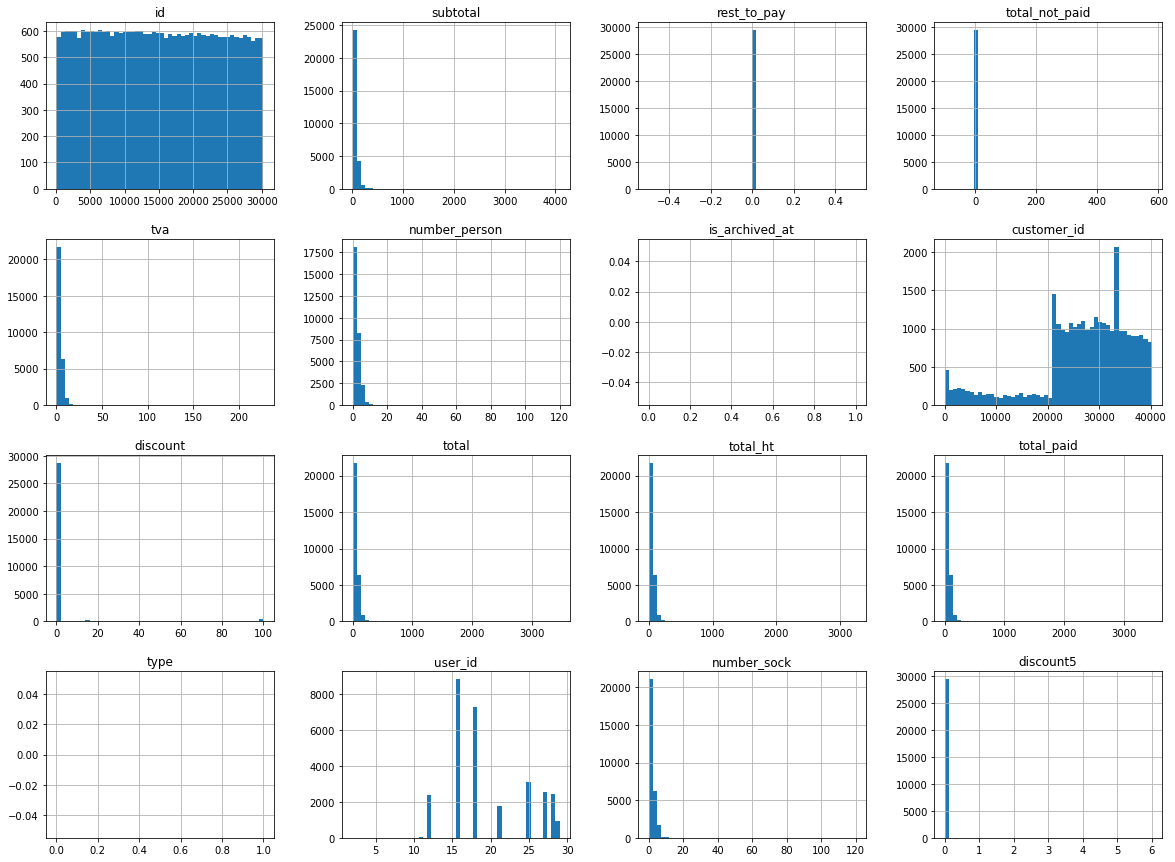

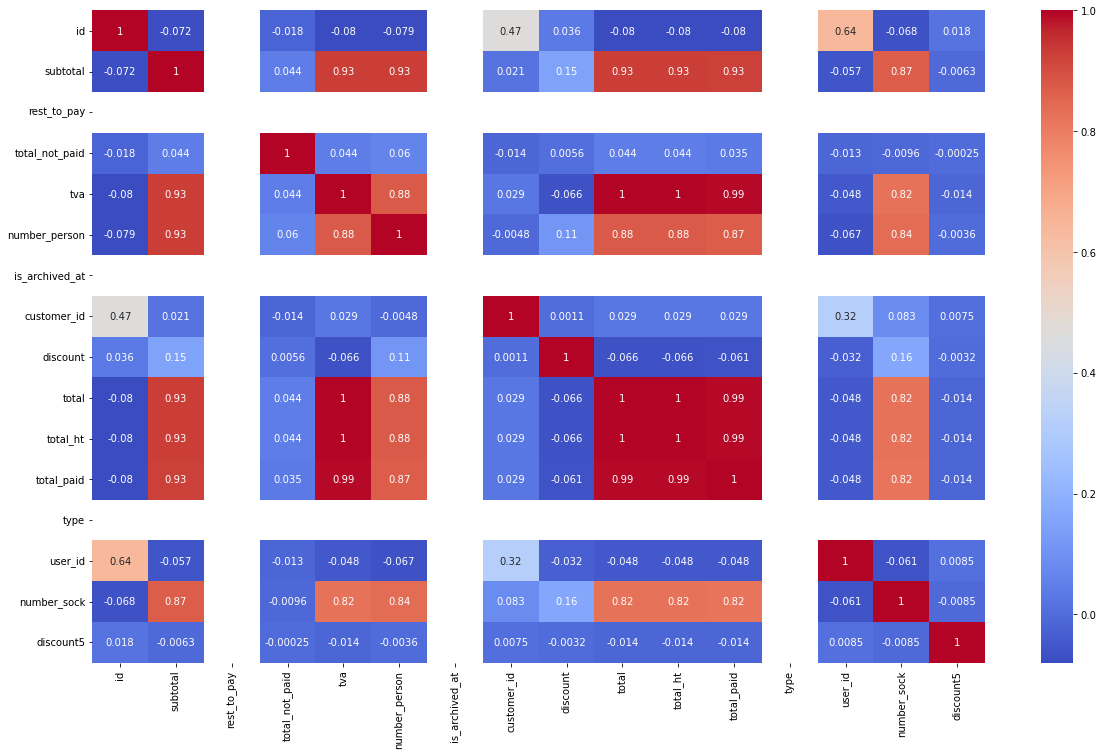

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for numerical columns
orders.hist(bins=50, figsize=(20,15))
plt.show()

# Box plots for numerical columns
# sns.boxplot(x='column_name', data=data)

# Scatter plots for relationships
# sns.scatterplot(x='column1', y='column2', data=data)

# Correlation heatmap
plt.figure(figsize=(20, 12))
corr_matrix = orders.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

Here's a summary of some notable correlations:

Subtotal and TVA: There's a strong positive correlation (0.93), indicating that as the subtotal increases, the tax value added (TVA) also increases proportionally.
Subtotal and Number of Persons: A strong positive correlation (0.93) here suggests that the subtotal tends to increase with the number of persons.
Total, Total HT, and Total Paid: All have a perfect or near-perfect correlation with each other (1 or close to 1), indicating these values are closely linked, which is expected as they represent different aspects of the total amount related to the orders.
Number of Persons and Number Sock: There's a strong positive correlation (0.84), suggesting that orders with more persons tend to have a higher number of socks (assuming "number_sock" refers to some quantity related to the orders).
Variables such as rest_to_pay and type have NaN correlations with others, which might be due to them having constant or null values across the dataset.

In [13]:
#Correlation between variables
correlation_matrix = orders.corr()

correlation_matrix

,id,subtotal,rest_to_pay,total_not_paid,tva,number_person,is_archived_at,customer_id,discount,total,total_ht,total_paid,type,user_id,number_sock,discount5
id,1.000000,-0.072435,NaN,-0.018324,-0.080353,-0.078718,NaN,0.465693,0.036100,-0.080353,-0.080353,-0.080336,NaN,0.640358,-0.067691,0.018071
subtotal,-0.072435,1.000000,NaN,0.044389,0.930020,0.931691,NaN,0.020620,0.150004,0.930020,0.930020,0.927913,NaN,-0.057279,0.869344,-0.006324
rest_to_pay,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_not_paid,-0.018324,0.044389,NaN,1.000000,0.043501,0.059914,NaN,-0.013995,0.005575,0.043501,0.043501,0.035080,NaN,-0.013172,-0.009624,-0.000250
tva,-0.080353,0.930020,NaN,0.043501,1.000000,0.875830,NaN,0.028913,-0.066300,1.000000,1.000000,0.994951,NaN,-0.048360,0.824203,-0.014493
number_person,-0.078718,0.931691,NaN,0.059914,0.875830,1.000000,NaN,-0.004823,0.111460,0.875831,0.875831,0.872853,NaN,-0.067337,0.836635,-0.003574
is_archived_at,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,0.465693,0.020620,NaN,-0.013995,0.028913,-0.004823,NaN,1.000000,0.001141,0.028912,0.028912,0.029019,NaN,0.319331,0.083330,0.007495
discount,0.036100,0.150004,NaN,0.005575,-0.066300,0.111460,NaN,0.001141,1.000000,-0.066300,-0.066300,-0.061341,NaN,-0.031735,0.162781,-0.003176
total,-0.080353,0.930020,NaN,0.043501,1.000000,0.875831,NaN,0.028912,-0.066300,1.000000,1.000000,0.994951,NaN,-0.048360,0.824204,-0.014493


In [11]:
orders.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
29366    False
29367    False
29368    False
29369    False
29370    False
Length: 29371, dtype: bool

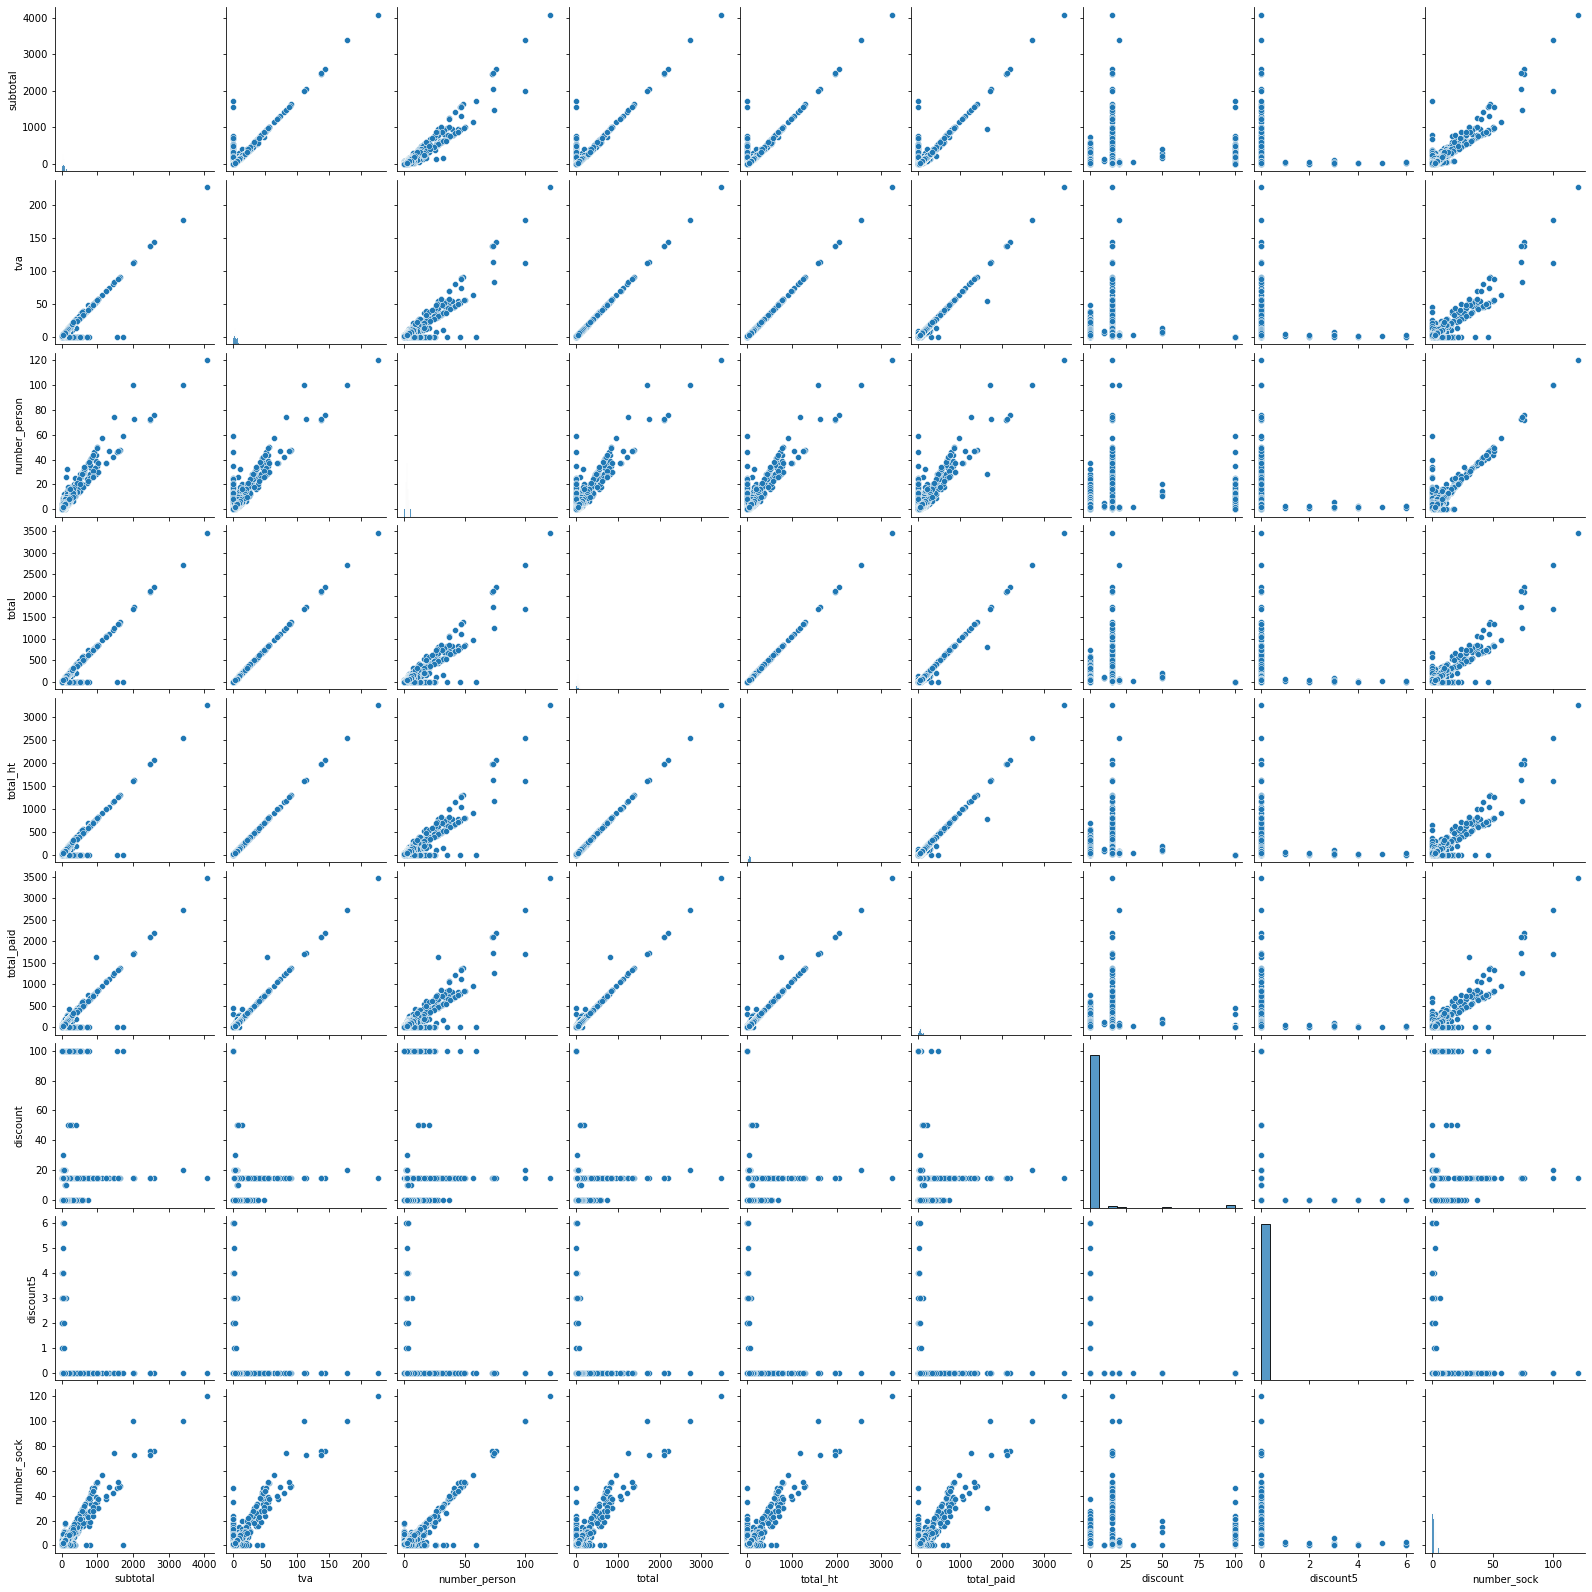

In [19]:
# Selecting a subset of columns for the pair plot, feel free to adjust these
selected_columns = ['subtotal', 'tva', 'number_person', 'total', 'total_ht', 'total_paid','discount','discount5','number_sock']

# Generating the pair plot
sns.pairplot(orders[selected_columns])